# ASTR21 Winter 2026 Sections 1 & 2 Notebook

In this notebook, we'll go through some basics of using python, Jupyter notebooks, and Colab. We'll also go through some examples
related to the material in sections 1 and 2. While we're at it, we'll import some of the python modules that we'll be using in the notebooks for later sections in the course.

This isn't an exhaustive tutorial for python, Jupyter notebooks, or Colab by any means. Here are a few links to additional tutorials that you may find useful!

* [Google Colab Tutorial](https://www.marqo.ai/blog/getting-started-with-google-colab-a-beginners-guide)

* [Overview of Colaboratory Features](https://colab.research.google.com/notebooks/basic_features_overview.ipynb): this goes through some of the important features of Colab and notebooks. So does this [tutorial!](https://colab.research.google.com/notebooks/intro.ipynb)

* [Jupyter](https://jupyter.org/): Colab is built on top of Jupyter Notebook, which you can find here. There are some tutorials linked from this website. Here's the [intro notebook](https://jupyter.org/try-jupyter/notebooks/?path=notebooks/Intro.ipynb) that you can find if you click "Try it in your browser" in the "Jupyter Notebook" section of the main page.

## Some Basics

To execute the cell below, click on it, and then either: (1) press SHIFT and ENTER at the same time, or (2) click the right arrow button on the left side of the cell.

In [ ]:
1+1

In [ ]:
# Starting a line with # turns it into a comment.
# The notebook won't run lines that start with #.
# They are just messages to you or someone else
# that help you keep track of what the code does.

# This cell does some arithmetic.
5-4

In [ ]:
# In the next two lines, we'll define two variables
# called a and b.
a = 4
b = 3

# The next line adds a and b.
a+b

In [ ]:
c = a*a       # This line multiplies a and b as a new variable called c.
print(c)      # This line tells the notebook to print the value of the variable c.

## Importing Modules

Let's import some modules for working with arrays, and for making plots.

In [ ]:
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import astropy.io.fits as pyfits

## Pulling Data From Github

In this course we'll be doing some in-class activities
where we load data from the class Github page. The
following cell shows you how to do this using a wget command
where you retrieve .zip archive from Github, and then
using a command to unpack the archive into a directory
that will exist in your Colab space.

In [ ]:
!wget https://github.com/bgaensler/astr21/raw/refs/heads/main/secs1to2_data.zip
!unzip -o secs1to2_data.zip -d .

In [ ]:
# Let's use numpy to load a list of dates and times that we'll use later in the notebook

dates = np.loadtxt('secs1to2_data/analemma_dates.txt',dtype=str)

## Saving Your Notebook

This notebook is running on a server that won't save your work if you close this tab.

To save the notebook, click on "File" and then "Save a copy in Drive." You'll then have a notebook saved in a Google Drive folder called "Collaboratory." You can open the notebook from there later.

If you want to save outputs like plots to your computer, you can right click on them and then choose "Save image as..." If you want to give this a try, you can do it for the plot generated by the following cell.

In [ ]:
# First we'll generate an array of 100 random numbers uniformly distributed
# between 0 and 1.
a = np.random.uniform(0,1,size=100)

# Next, we'll scatter plot those 100 numbers as y values, against their
# positions in the array as x values.

plt.scatter(range(100),a)
plt.ylabel('Random Number')
plt.xlabel('Position')
plt.show()

## Let's collect data from Stellarium and make a plot!

In this activity, we're going to use Stellarium-Web to find the horizontal coordinates of the Sun at a consistent wall-clock time over the course of 2025-2026!

The first thing that we should do is print the values inside the "analemma_dates.txt" file, which we saved as an array earlier in the notebook. This array tells us what dates and local times (assuming daylight savings) to use to find the Sun's AZ and ALT.

The reason we're assuming daylight savings is that Stellarium-Web (see below) is going to use your laptop's time settings no matter what location or date you give it. This is a known Stellarium quirk that we're going to work around!

In [ ]:
print(dates)

Great! Now that you've got those, go to [Stellarium Web](https://stellarium-web.org/) and click on the location in the bottom left corner (circled in red below) to change your location to one of your team's choice! I'm going to go ahead and choose Boston, Massachusetts (where I got married and my son was born).


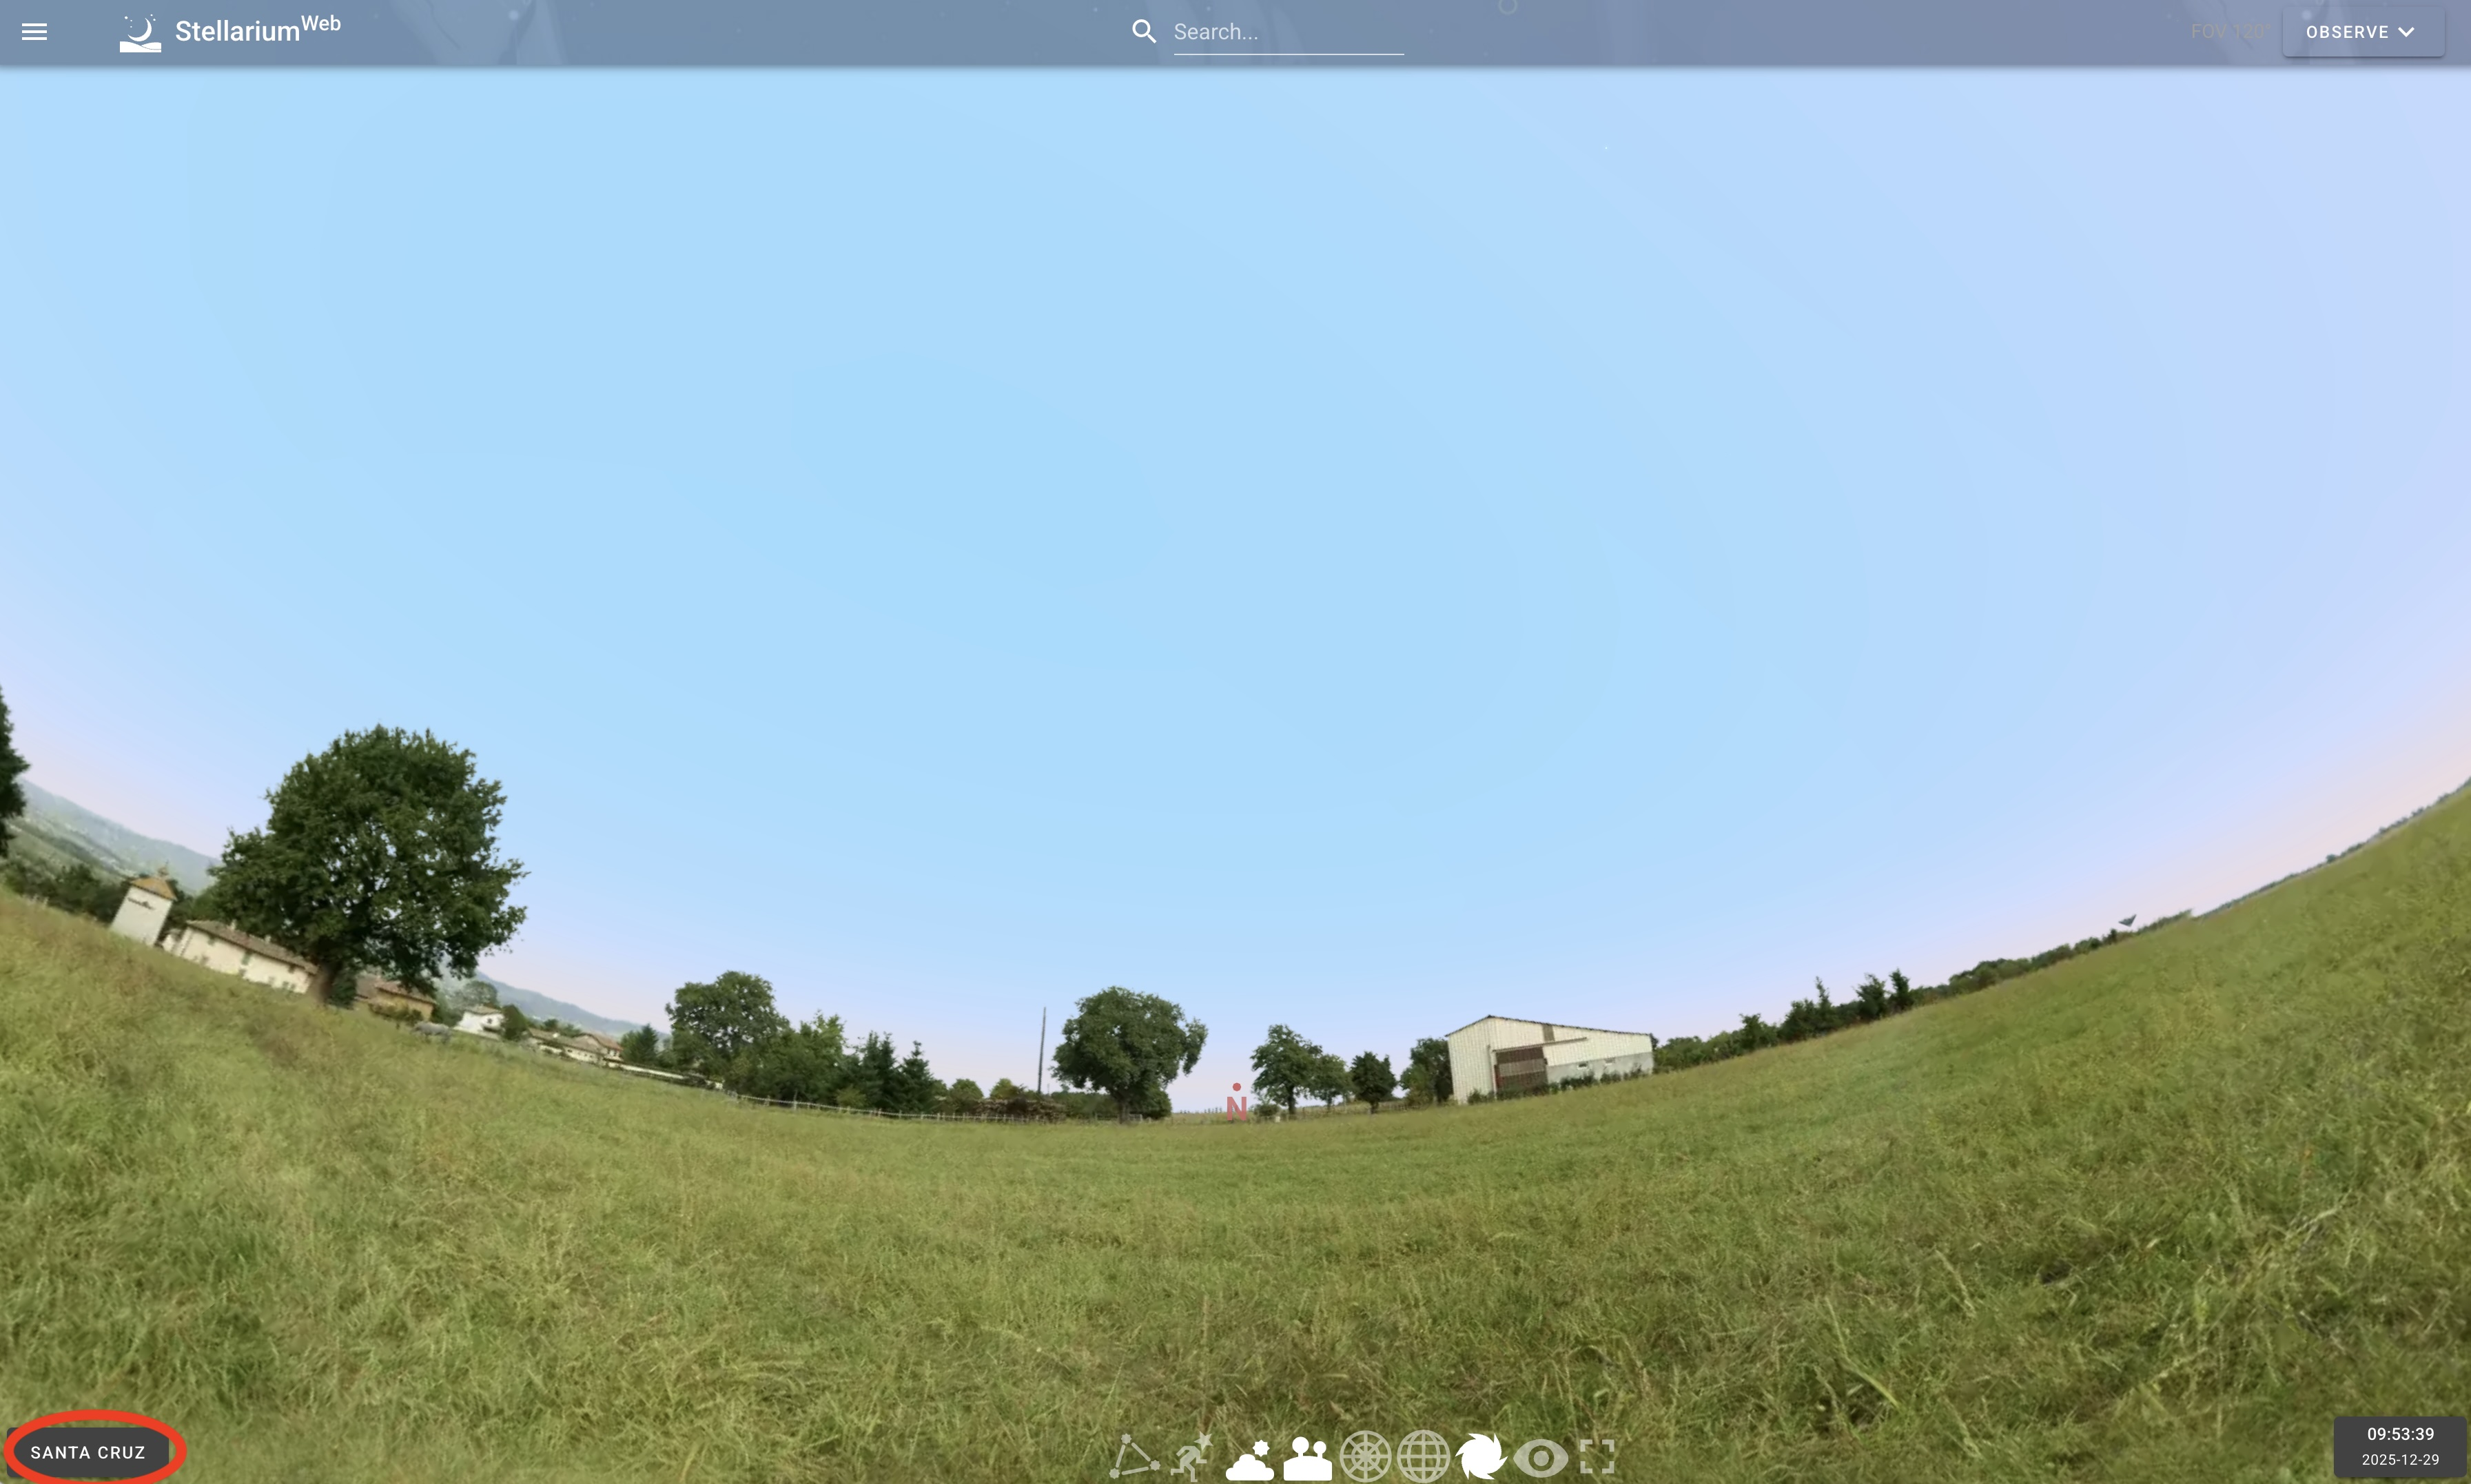

Next, let's change the time to 12:00:00 (click on the time at bottom right, press "Pause", and then adjust the time), and then look up the Sun by typing "Sun" into the search bar at the top, and selecting it.

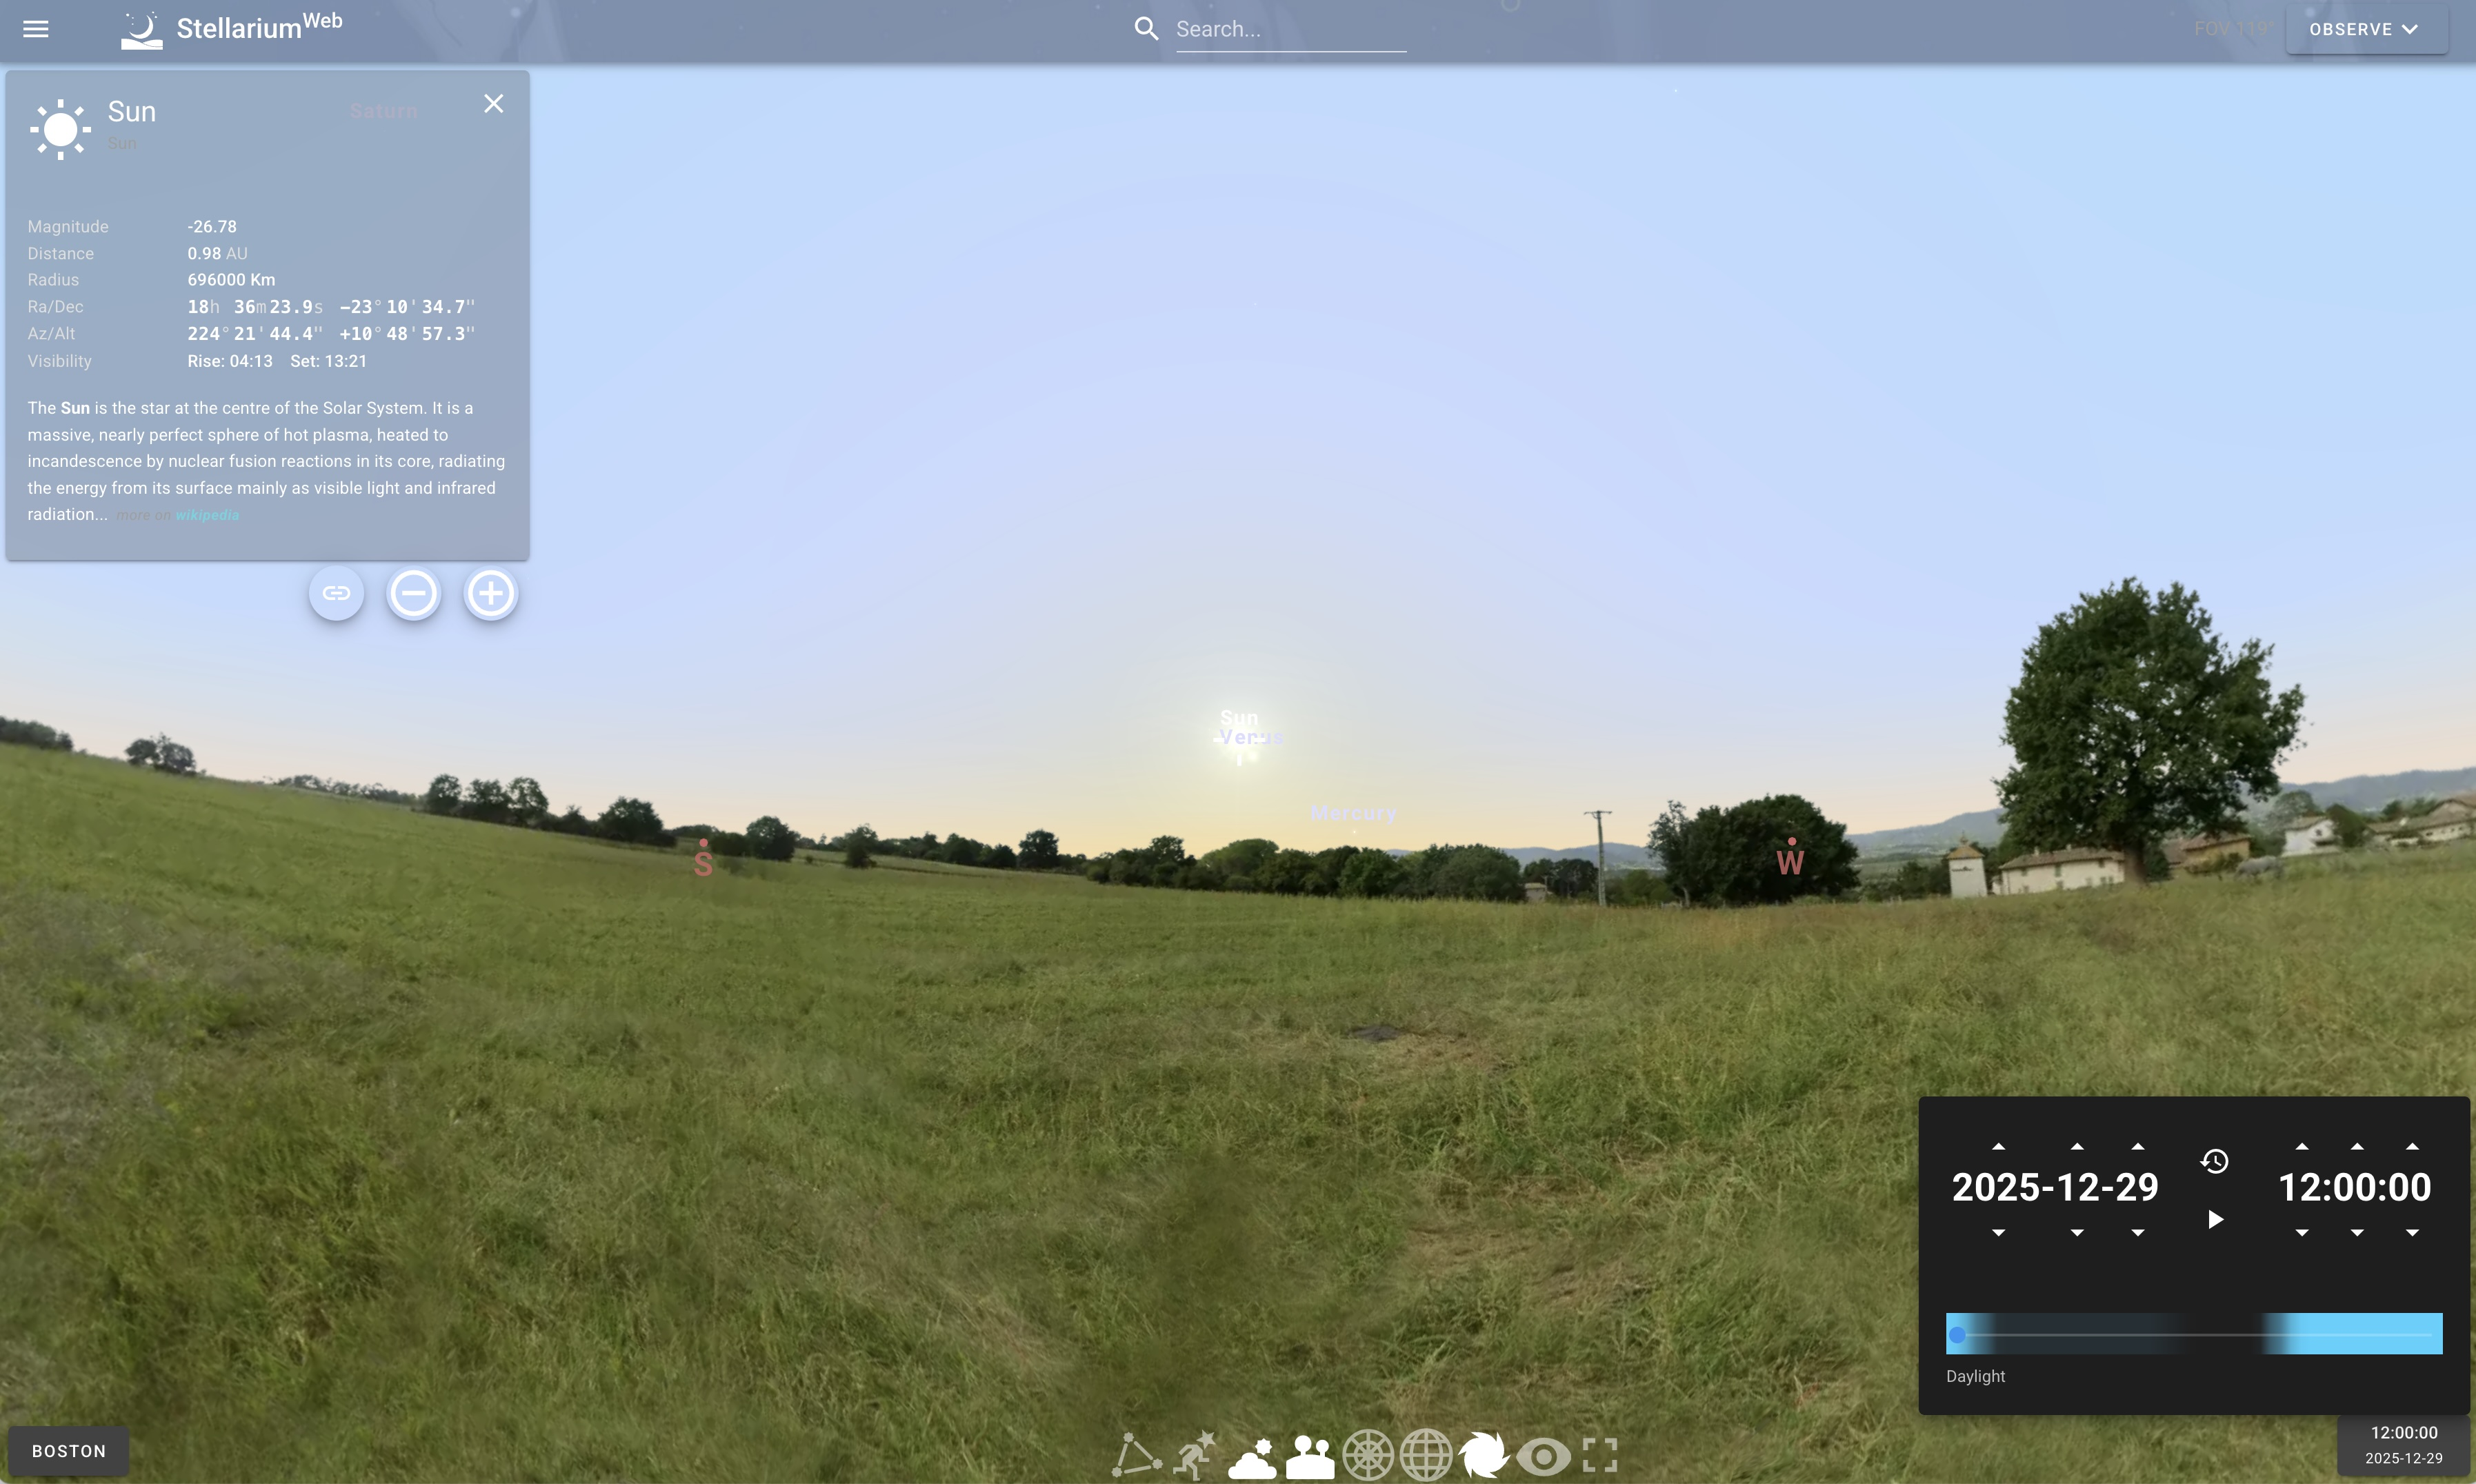

Next, we can turn on the grid that shows us horizontal coordinates! That's the first of the two circular grid icons at the bottom of the screen.

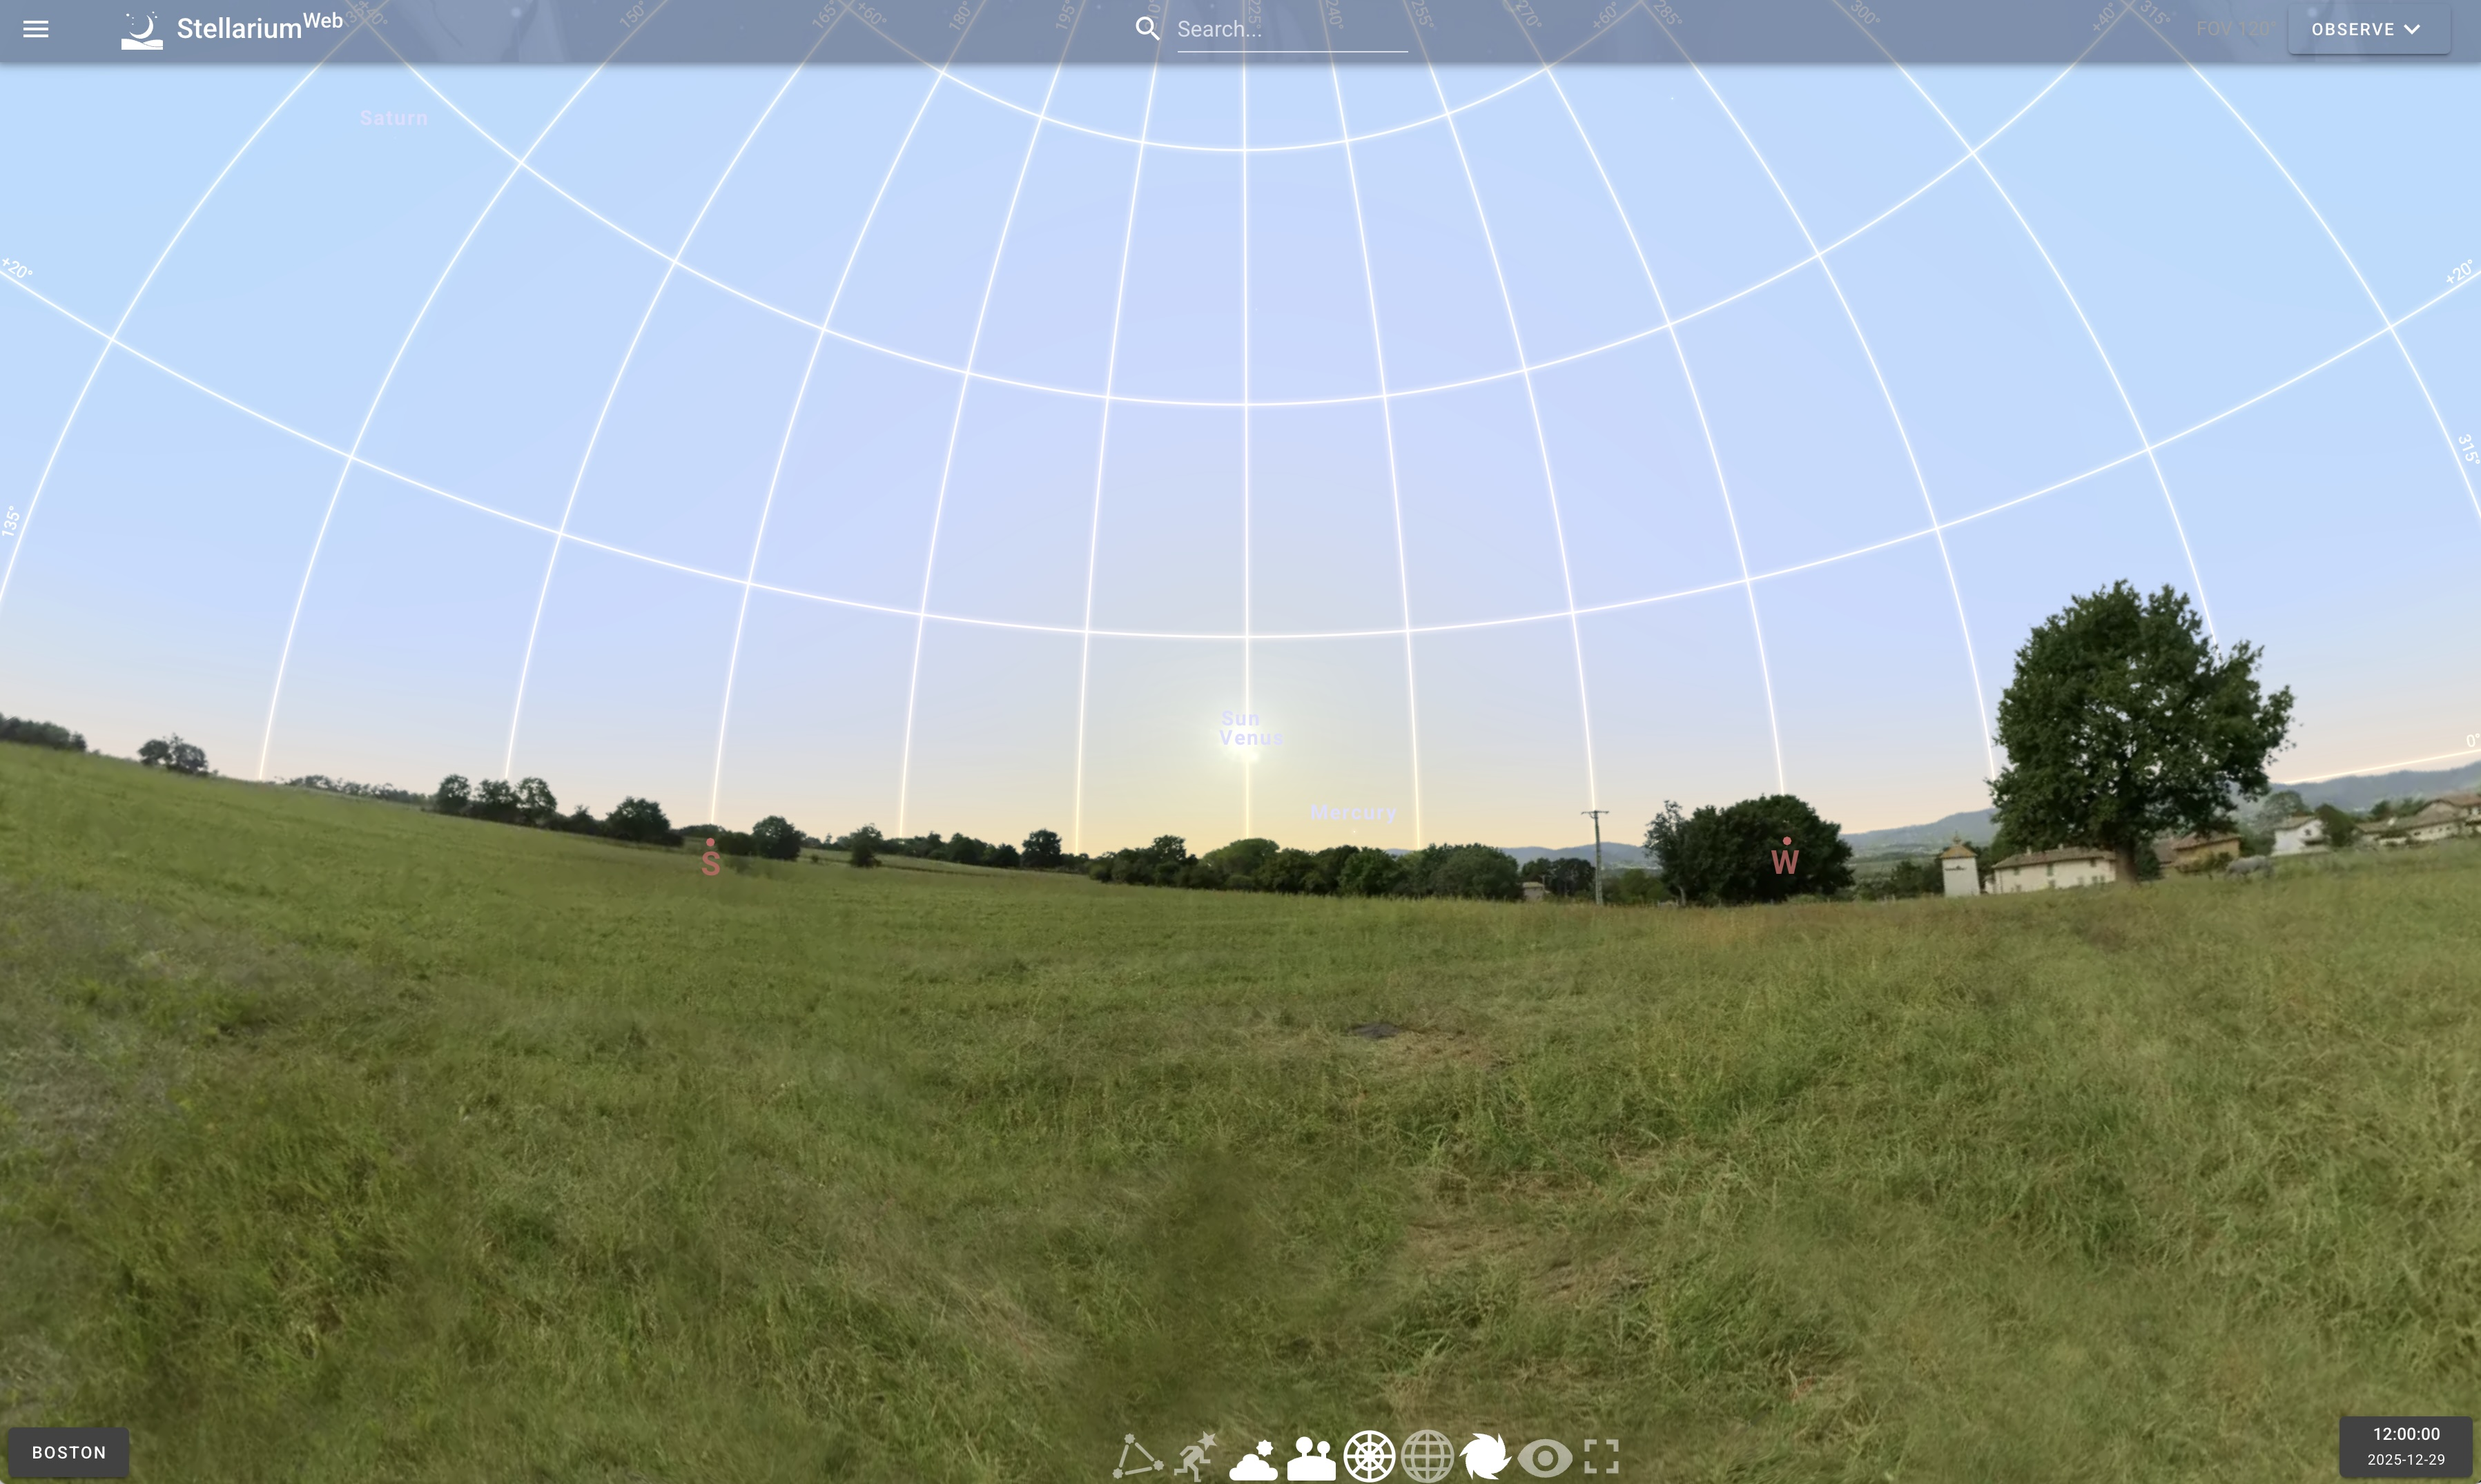

The last thing we need to do is change the time and date to the one we want. I'll use the first date and time from the list.

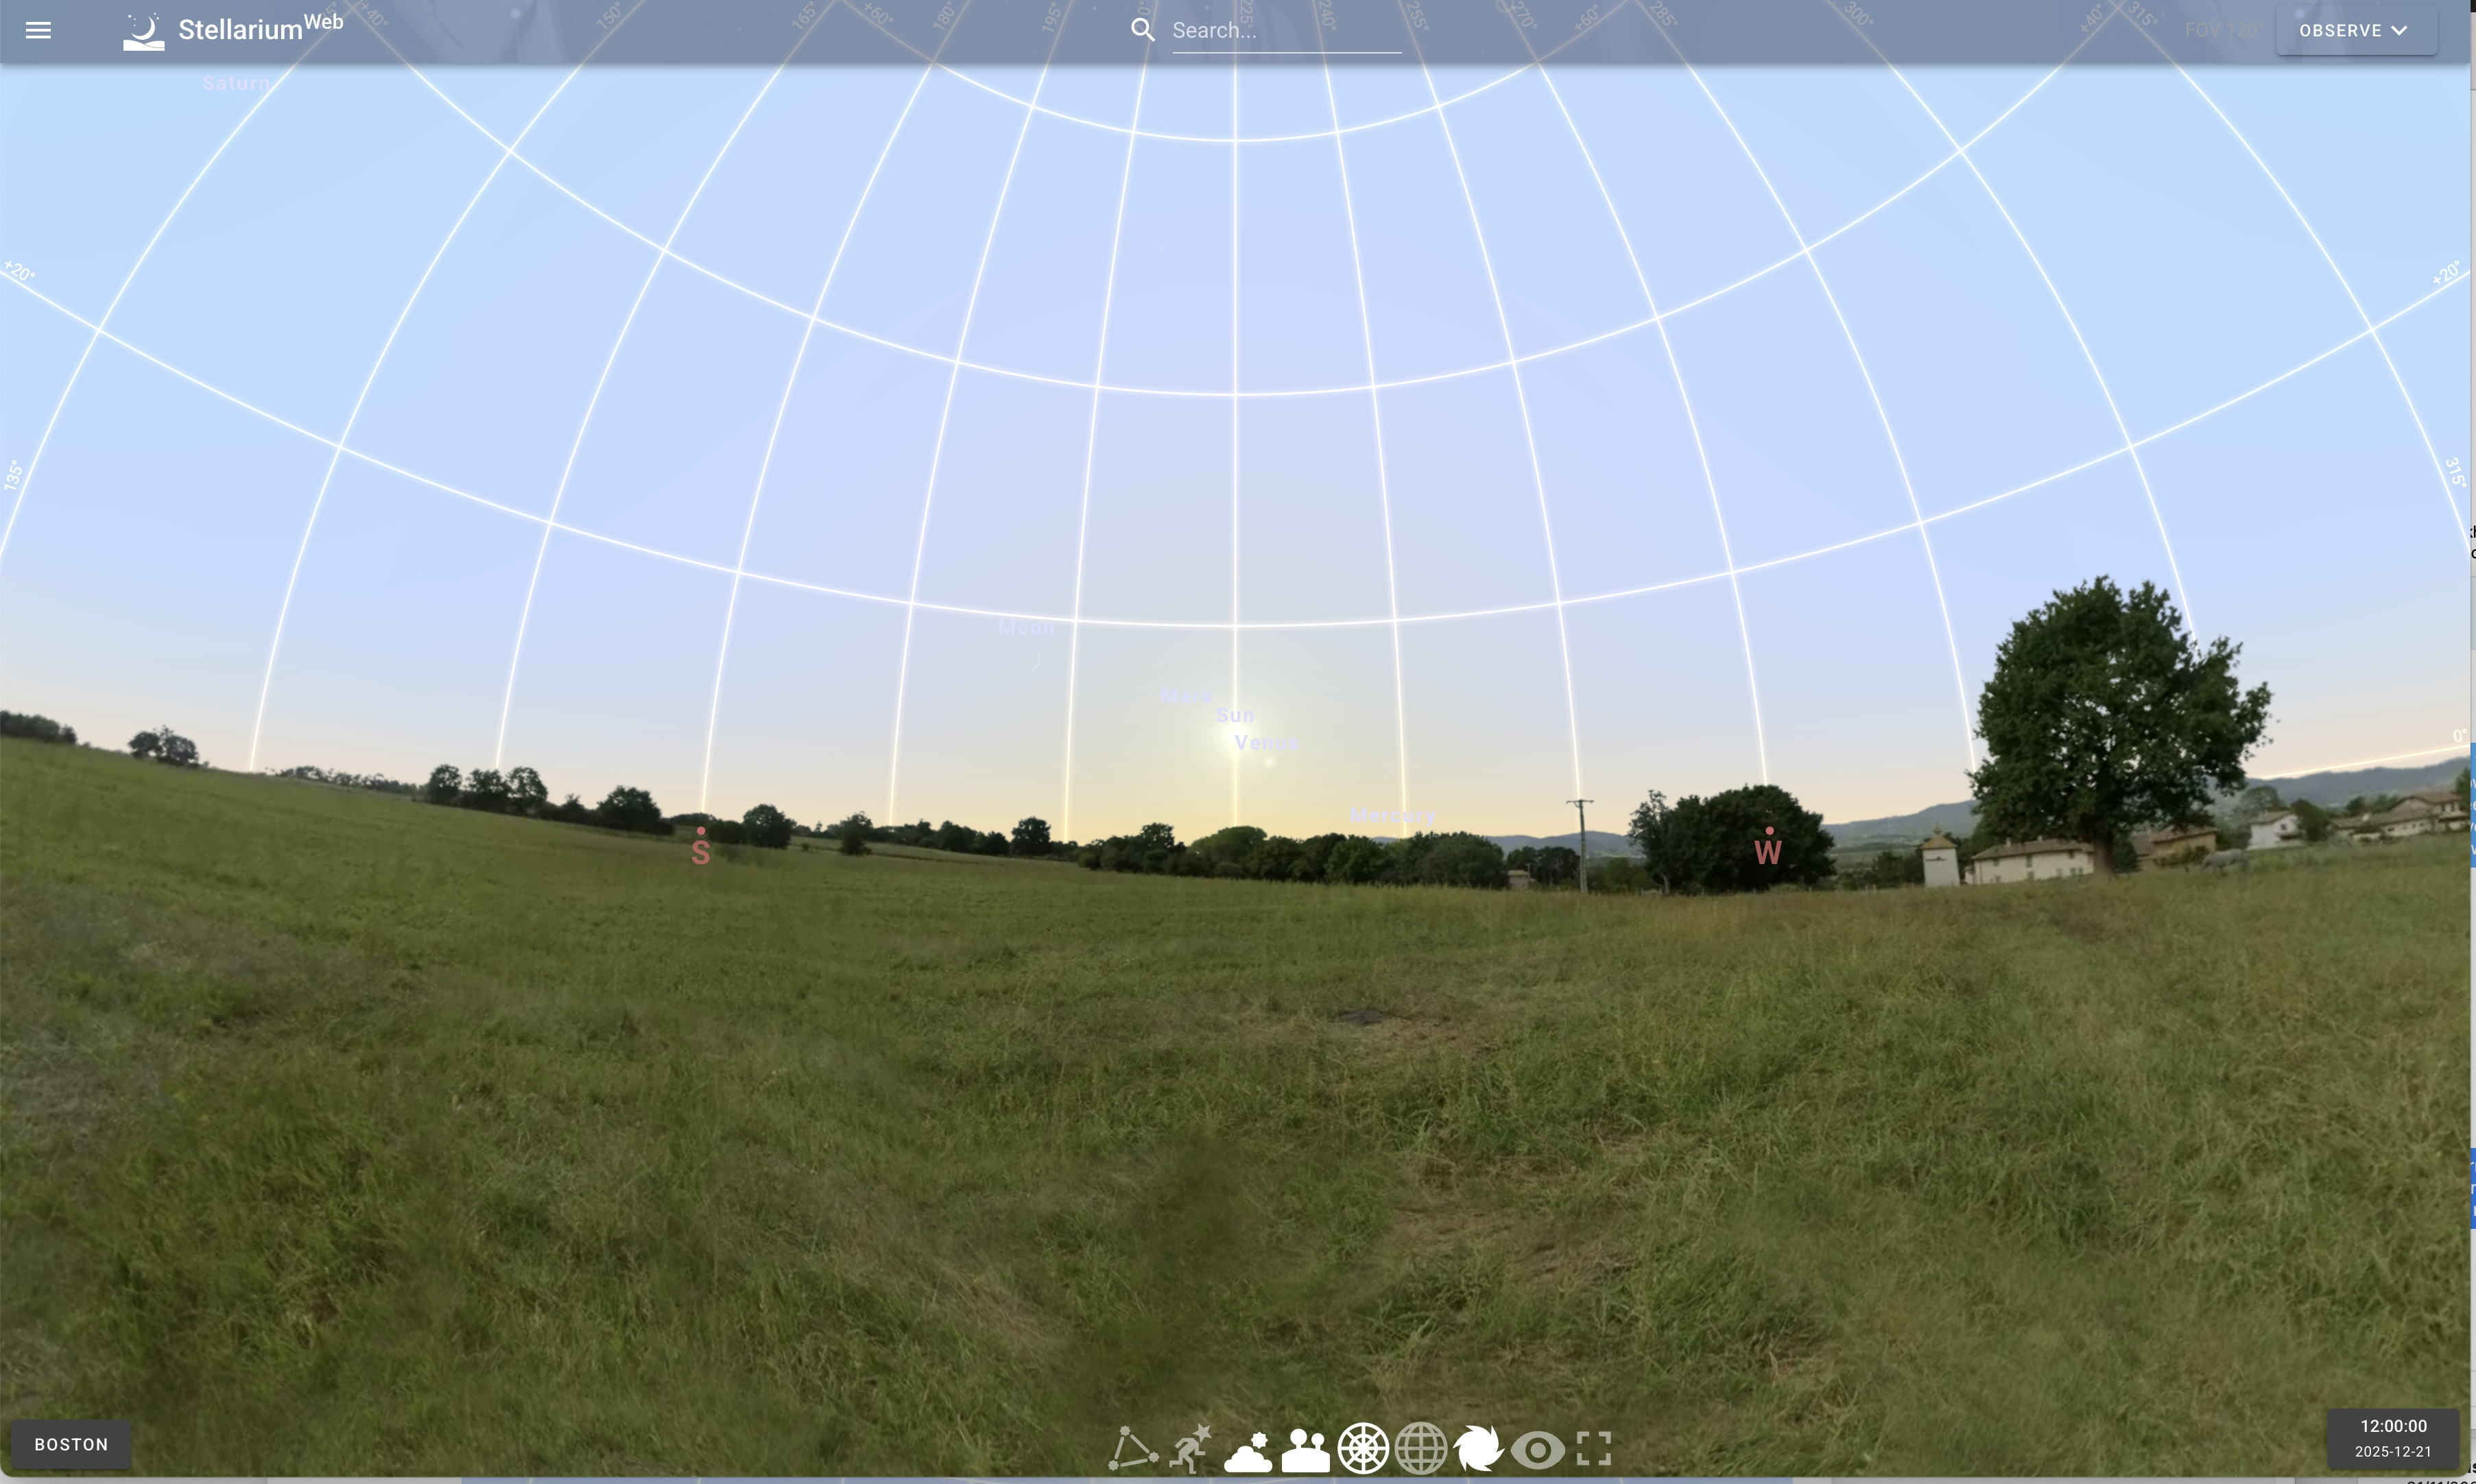

This is where things get a little weird! If you look at the screenshot above, you'll notice that I've set the time to be 12:00 noon, but the Sun has almost set in Massachusetts!

This is because Stellarium Web sets the time based on the time on your laptop. So in order to select noon in Massachusetts, I have to enter the time in California, which is 9:00 am. Let's fix that.

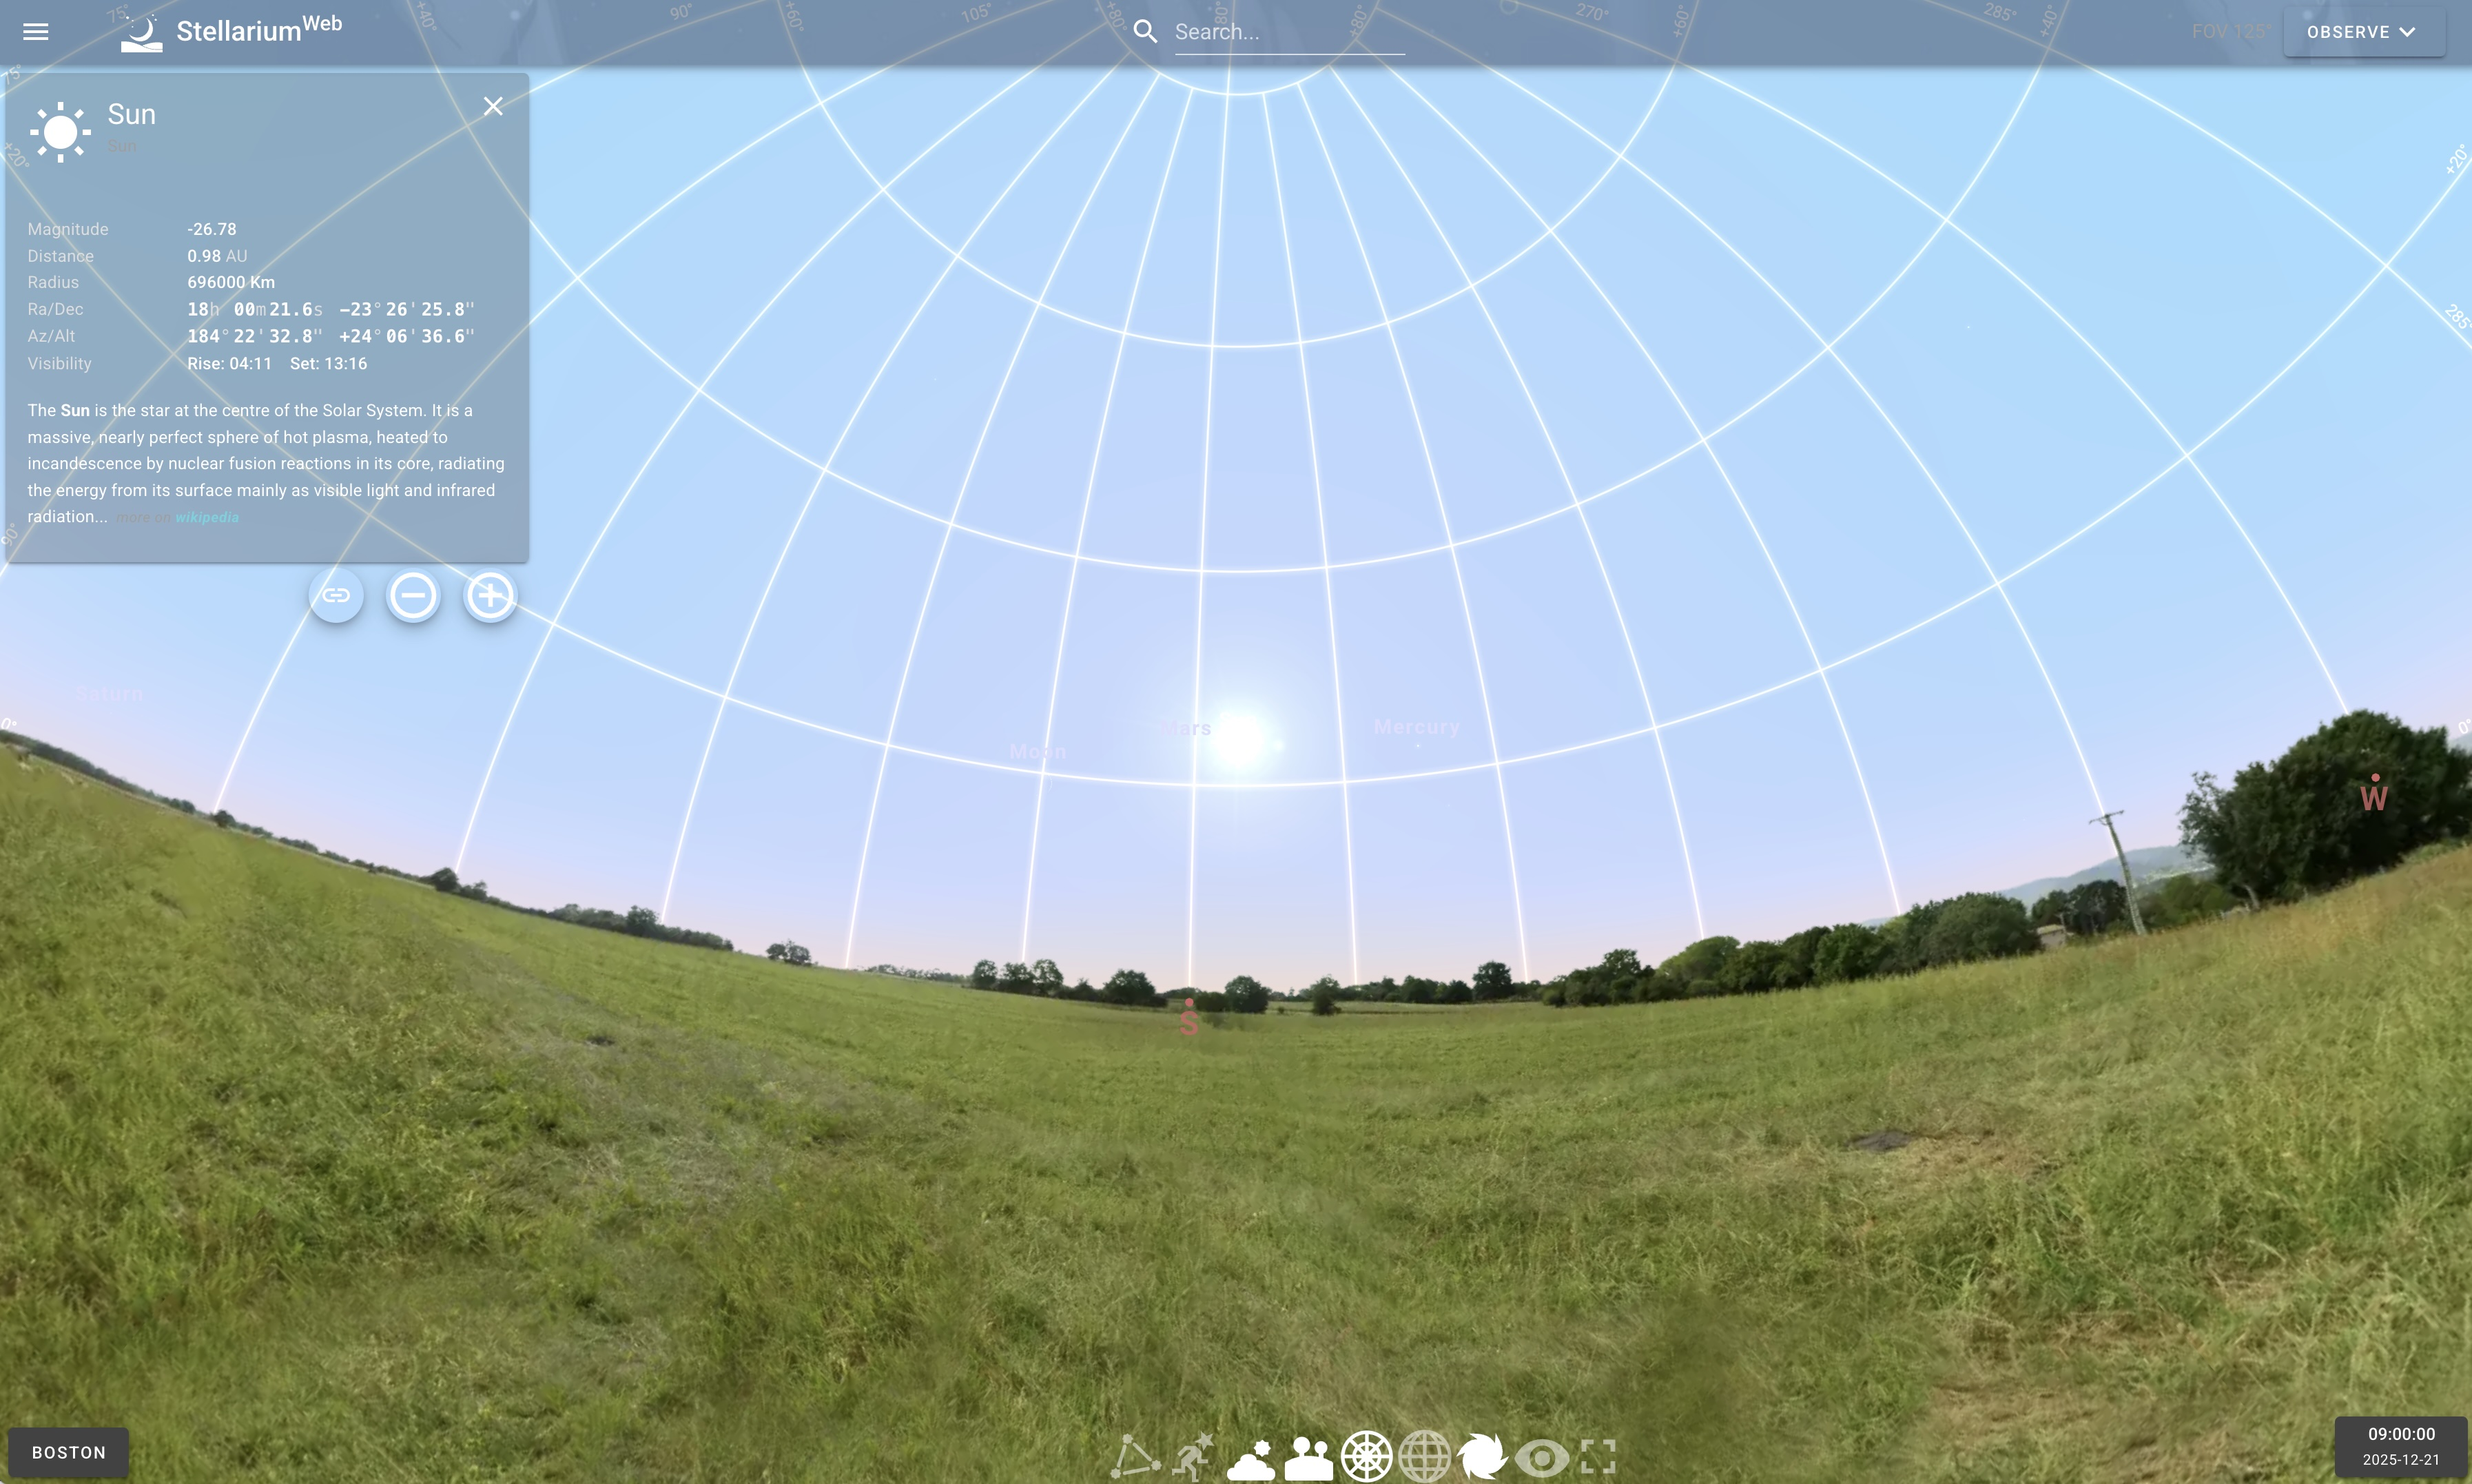

Now when you look at the info box for the Sun, you can see its azimuth and altitude at noon in the correct time zone! Note that for the dates where I should be using 1 pm local (Massachusetts) time, I'll need to adjust to 10 am California time.

**NOTE**: The times listed in the "dates" file above are set up for those parts of the USA and Canada that observe daylight savings. 
* If you've picked somewhere in USA/Canada that does not observe daylight savings (e.g., Arizona, Hawaii, Yukon), then you should use 12pm every month; do not switch to 1pm for some months.
* If you've picked somewhere in a country that does not observe daylight savings (e.g., Mexico, South Africa), you should similarly use 12pm every month.
* If you've picked any other country that uses daylight savings, you'll have to adjust between 12pm and 1pm for the corresponding dates of the year for that country (see, e.g., https://www.timeanddate.com/time/dst/). For countries in the Southern Hemisphere, the ordering between 12pm and 1pm will be reversed too!
* If you pick somewhere inside the Arctic or Antarctic circles, everything will still work, but bear in mind that the Sun will be below the horizon for 6 months of the year.

In this exercise, we want to plot the altitude vs azimuth of the Sun in units of degrees. But Stellarium gives us degrees, arcminutes, and arcseconds. Let's define a function that will take those three values and give us units of degrees!

The cell below has the function set up for you. This function takes degrees, arcminutes, and arcseconds, and returns decimal degrees.

In [ ]:
def to_ddeg(deg,arcmin,arcsec):
  ddeg = deg + arcmin/60.0 + arcsec/(60.0*60.0)
  return ddeg

Let's try it out with the values of deg, arcmin, and arcsec for ALT and AZ in the screenshot above!

In [ ]:
print('AZ = ',to_ddeg(184,22,32.8)) #AZ
print('ALT = ',to_ddeg(24,6,36.6)) #ALT

We now have our values in units of degrees!

Split your dates and times amongst your teammates, and generate a list of AZ and ALT values in decimal degrees.

In the next cell, enter those values for at least the 12 dates (feel free to add more), by copying the decimal degrees for each date into the list. Be careful that the two lists are in the same order! The cell below has an example using my first five dates.

In [ ]:
AZs = [184.37577777777778,181.179277777777778,180.6919722222222,183.2530555555555,188.26097222222222]
ALTs = [24.110166666666668,27.8681944444444444,37.27455555555556,48.03361111111111,59.44502777777777]

Once you've populated your list after using Stellarium for each date, make a plot using your two lists, to see how the Sun's position at noon changes throughout the year! The cell below has an example for my two lists.

In [ ]:
# Make the figure
fig = plt.figure()
ax = fig.add_subplot(111)

# Plot the data
ax.scatter(AZs, ALTs)


# Add a title
plt.title('Altitude and Azimuth Plot')

# Label the axes
plt.xlabel('Azimuth (deg)')
plt.ylabel('Altitude (deg)')

# Show the plot
plt.show()

## Let's add many dates to the plot using the [PySolar module](https://pysolar.readthedocs.io/en/latest/)!

PySolar probably isn't installed, so we're first going to install it in our virtual environment.

In [ ]:
pip install pysolar

Now we can load up PySolar, along with some other modules that will help us manipulate date and time.

In [ ]:
import pysolar as ps
import datetime # to generate datetime objects
import pytz # generate a timezone object
import matplotlib.pyplot as plt # performing plots

Next, set the following latitude, longitude, and time zone variables to match your location in Stellarium! I'll use Boston's coordinates. For a list of time zones available, visit this website: https://gist.github.com/heyalexej/8bf688fd67d7199be4a1682b3eec7568

In [ ]:
lat_me = 42.35883 #latitude
long_me = -71.05783 #longitude
tz = pytz.timezone('US/Eastern') #time zone

The cell below is going to loop through an entire year of dates and plot the AZ and ALT of the Sun. Let's see if it matches the data collected from Stellarium!

In [ ]:
azi = []
alti = []
ana_date = tz.localize(datetime.datetime(2026,1,21,12,0)) # Set the first date of the year

for ii in range(0,364):
    ana_date = tz.normalize(ana_date + datetime.timedelta(days=1)) # increment by a single day
    altitude = ps.solar.get_altitude(lat_me, long_me, ana_date) # get the Sun's altitude
    azimuth = ps.solar.get_azimuth(lat_me, long_me, ana_date) # get the Sun's azimuth
    azi.append(azimuth) # append the Sun's azimuth to the list
    alti.append(altitude) # append the Sun's altitude to the list

plt.scatter(azi, alti, c='grey',label='PySolar')
plt.scatter(AZs,ALTs,c='r',label='Stellarium')
plt.legend()
plt.show()

The grey points above outline what we call the "analemma", which is the Sun's changing ALT and AZ throughout the year for a fixed wall-clock time!


### Are the coordinates above matching up well? If so, great! If not, can you adjust your location slightly to get the analemmas to match?

Play around with the latitude and longitude in the cell below to see if you can get the red points to match up better.


In [ ]:
lat_me = 42
long_me = -70
tz = pytz.timezone('US/Eastern')

azi = []
alti = []
ana_date = tz.localize(datetime.datetime(2026,1,21,12,0)) # Set the first date of the year

for ii in range(0,364):
    ana_date = tz.normalize(ana_date + datetime.timedelta(days=1)) # increment by a single day
    altitude = ps.solar.get_altitude(lat_me, long_me, ana_date) # get the Sun's altitude
    azimuth = ps.solar.get_azimuth(lat_me, long_me, ana_date) # get the Sun's azimuth
    azi.append(azimuth) # append the Sun's azimuth to the list
    alti.append(altitude) # append the Sun's altitude to the list

plt.scatter(azi, alti, c='grey',label='PySolar')
plt.scatter(AZs,ALTs,c='r',label='Stellarium')
#plt.xlim(0,360) #uncomment if you want to change the x axis range on the plot
plt.legend()
plt.show()

### Let's try changing a few more things to understand how the analemma looks in different places!
The cell below has the red points removed. Change the longitude and time zone to see how the analemma changes. Compare your plot here to the grey points in the plot above this cell to see how the longitude change affected the analemma.

Did the longitude change affect the vertical extent of the analemma? Did it affect the horizontal extent of the analemma?

For a list of time zones, check out this website https://gist.github.com/heyalexej/8bf688fd67d7199be4a1682b3eec7568, and be sure to make your time zone match your longitude!

In [ ]:
lat_me = 42.35883
long_me = -122 ###CHANGE ME!
tz = pytz.timezone('US/Pacific') ###CHANGE ME!

azi = []
alti = []
ana_date = tz.localize(datetime.datetime(2026,1,21,12,0,0)) # Set the first date of the year

for ii in range(0,364):
    ana_date = tz.normalize(ana_date + datetime.timedelta(days=1)) # increment by a single day
    altitude = ps.solar.get_altitude(lat_me, long_me, ana_date) # get the Sun's altitude
    azimuth = ps.solar.get_azimuth(lat_me, long_me, ana_date) # get the Sun's azimuth
    azi.append(azimuth) # append the Sun's azimuth to the list
    alti.append(altitude) # append the Sun's altitude to the list

plt.scatter(azi, alti, c='grey',label='PySolar')
#plt.xlim(0,360) #uncomment if you want to change the x axis range on the plot
plt.legend()
plt.show()

The cell below has the red points removed. Keep your longitude and time zone values from the previous cell, and set the latitude to a different value to see how the analemma changes. Compare the next plot to the one in the cell above to see how the latitude change affected the analemma.

Did the latitude change affect the vertical extent of the analemma? Did it affect the horizontal extent of the analemma?

You shouldn't need to change the time zone for this test!

In [ ]:
lat_me = 15 ###CHANGE ME!
long_me = -122 ###LEAVE ME THE SAME AS IN THE LAST CELL!
tz = pytz.timezone('US/Pacific') ###LEAVE ME THE SAME AS IN THE LAST CELL!

azi = []
alti = []
ana_date = tz.localize(datetime.datetime(2026,1,21,12,0,0)) # Set the first date of the year

for ii in range(0,364):
    ana_date = tz.normalize(ana_date + datetime.timedelta(days=1)) # increment by a single day
    altitude = ps.solar.get_altitude(lat_me, long_me, ana_date) # get the Sun's altitude
    azimuth = ps.solar.get_azimuth(lat_me, long_me, ana_date) # get the Sun's azimuth
    azi.append(azimuth) # append the Sun's azimuth to the list
    alti.append(altitude) # append the Sun's altitude to the list

plt.scatter(azi, alti, c='grey',label='PySolar')
#plt.xlim(0,360) #uncomment if you want to change the x axis range on the plot
plt.legend()
plt.show()

Compare the change with longitude to the change with latitude. After the tests above, what is the full vertical extent of the analemma, and what do you think causes the vertical variation? And what do you think causes the horizontal variation? 



Now let's add some (complicated!) code that lets us adjust the tilt of the Earth's orbit and the eccentricity of the Earth's orbit (eccentrity of 0 is a perfect circle; numbers larger than 0 correspond to ellipses).

Don't worry if you can't understand this code. It involves some complex orbital calcultions that are way beyond the scope of this course.

In [ ]:
import numpy as np
import datetime as dt
from zoneinfo import ZoneInfo

# ---- time / angles helpers ----
DEG2RAD = np.pi/180.0
RAD2DEG = 180.0/np.pi

def julian_day(t_utc: dt.datetime) -> float:
    """Julian Day for aware UTC datetime."""
    if t_utc.tzinfo is None:
        raise ValueError("t_utc must be timezone-aware UTC datetime")
    t_utc = t_utc.astimezone(dt.timezone.utc)
    y, m = t_utc.year, t_utc.month
    D = t_utc.day + (t_utc.hour + (t_utc.minute + t_utc.second/60)/60)/24
    if m <= 2:
        y -= 1
        m += 12
    A = y // 100
    B = 2 - A + (A // 4)
    JD = int(365.25*(y + 4716)) + int(30.6001*(m + 1)) + D + B - 1524.5
    return JD

def gmst_rad(JD: float) -> float:
    """Greenwich Mean Sidereal Time (radians), decent accuracy."""
    T = (JD - 2451545.0)/36525.0
    gmst_deg = (280.46061837 +
                360.98564736629*(JD - 2451545.0) +
                0.000387933*T*T -
                (T*T*T)/38710000.0)
    return (gmst_deg % 360.0) * DEG2RAD

def solve_kepler(M, e, iters=12):
    """Solve M = E - e sin E for eccentric anomaly E (radians)."""
    E = M
    for _ in range(iters):
        E = E - (E - e*np.sin(E) - M) / (1 - e*np.cos(E))
    return E
    
# ---- solar position (Meeus-style, simplified) ----
def sun_ra_dec(JD: float, tilt_deg_override=None, ecc_override=None):
    """
    Apparent-ish Sun RA/Dec (radians). Good enough to match Stellarium's analemma shape/placement closely.
    tilt_deg_override: if set, forces obliquity (axial tilt) to that value in degrees.
    """
    T = (JD - 2451545.0)/36525.0

    # Mean longitude (deg) and mean anomaly (deg)
    L0 = (280.46646 + 36000.76983*T + 0.0003032*T*T) % 360.0
    M  = (357.52911 + 35999.05029*T - 0.0001537*T*T) % 360.0
    
    # Eccentricity of Earth's orbit (or override)
    if ecc_override is None:
        ecc = 0.016708634 - 0.000042037*T - 0.0000001267*T*T
    else:
        ecc = float(ecc_override)

  # Mean anomaly (radians)
    Mr = M * DEG2RAD

    # Solve Kepler to get true anomaly nu
    E = solve_kepler(Mr, ecc)
    nu = 2*np.arctan2(np.sqrt(1+ecc)*np.sin(E/2), np.sqrt(1-ecc)*np.cos(E/2))

    # True ecliptic longitude (deg): L0 + (nu - M)
    # (nu and Mr are radians; convert delta to degrees)
    true_long = (L0 + (nu - Mr) * RAD2DEG) % 360.0

    # Apparent longitude correction (deg) (aberration-ish)
    omega = (125.04 - 1934.136*T) * DEG2RAD
    lam = (true_long - 0.00569 - 0.00478*np.sin(omega)) * DEG2RAD  # ecliptic longitude in rad

    # Obliquity (deg): either real (with small nutation term) or override
    if tilt_deg_override is None:
        eps0 = 23.439291 - 0.0130042*T - 1.64e-7*T*T + 5.04e-7*T*T*T
        eps = (eps0 + 0.00256*np.cos(omega)) * DEG2RAD
    else:
        eps = float(tilt_deg_override) * DEG2RAD

    # Convert ecliptic -> equatorial
    sin_lam, cos_lam = np.sin(lam), np.cos(lam)
    sin_eps, cos_eps = np.sin(eps), np.cos(eps)

    ra  = np.arctan2(cos_eps*sin_lam, cos_lam) % (2*np.pi)
    dec = np.arcsin(sin_eps*sin_lam)
    return ra, dec

def alt_az_from_ra_dec(JD: float, ra: float, dec: float, lat_deg: float, lon_deg: float):
    """Topocentric-ish alt/az from RA/Dec using GMST (ignores parallax; fine for Sun analemma)."""
    lat = lat_deg * DEG2RAD
    lon = lon_deg * DEG2RAD

    lst = (gmst_rad(JD) + lon) % (2*np.pi)
    H = (lst - ra + np.pi) % (2*np.pi) - np.pi  # hour angle in [-pi, pi]

    sin_alt = np.sin(lat)*np.sin(dec) + np.cos(lat)*np.cos(dec)*np.cos(H)
    alt = np.arcsin(sin_alt)

    # Azimuth from north, clockwise
    cos_az = (np.sin(dec) - np.sin(alt)*np.sin(lat)) / (np.cos(alt)*np.cos(lat))
    cos_az = np.clip(cos_az, -1, 1)
    az = np.arccos(cos_az)
    if np.sin(H) > 0:
        az = 2*np.pi - az

    return az*RAD2DEG, alt*RAD2DEG


def refract_altitude_deg(alt_true_deg, pressure_hpa=1010.0, temp_C=10.0):
    """
    Convert true (geometric) altitude to apparent altitude by adding atmospheric refraction.
    Bennett-style formula. Good for typical Stellarium-style comparisons.

    alt_true_deg: true altitude in degrees
    pressure_hpa: local pressure (hPa). Sea level ~1013.
    temp_C: temperature in Celsius
    """
    alt = float(alt_true_deg)

    # Refraction formula becomes unstable far below horizon; clamp a bit.
    if alt < -1.0:
        return alt_true_deg  # below horizon, leave unchanged (or you can still apply with care)

    # Bennett (1982) / common astronomical approximation:
    # R (arcminutes) = 1.02 / tan( (alt + 10.3/(alt+5.11)) in degrees )
    R_arcmin = 1.02 / np.tan(np.deg2rad(alt + 10.3/(alt + 5.11)))

    # Scale for pressure and temperature:
    # multiply by (P/1010) * (283/(273+T))
    R_arcmin *= (pressure_hpa / 1010.0) * (283.0 / (273.0 + temp_C))

    # Convert to degrees
    R_deg = R_arcmin / 60.0

    return alt_true_deg + R_deg




Let's set the true tilt and eccentricity for the Earth.

In [ ]:
# True tilt is 23.44 (degrees)
# True eccentricity is 0.0167 (dimensionless)

tilt_deg = 23.44
ecc = 0.0167

Now let's redo the analemma for Boston (or your favorite location) to make sure this new code still works.

In [ ]:
lat_me = 42.35883 #latitude
long_me = -71.05783 #longitude
tz = pytz.timezone('US/Eastern') #time zone

In [ ]:
azi = []
alti = []

ana_date = dt.datetime(2026, 1, 21, 12, 0, tzinfo=tz)  # zoneinfo-aware

for ii in range(365):
    t_local = ana_date + dt.timedelta(days=ii)              # same civil time each day
    t_utc   = t_local.astimezone(dt.timezone.utc)           # convert to UTC for JD/GMST

    JD = julian_day(t_utc)
    ra, dec = sun_ra_dec(JD, tilt_deg_override=tilt_deg, ecc_override=ecc)
    azimuth, altitude = alt_az_from_ra_dec(JD, ra, dec, lat_me, long_me)
    altitude = refract_altitude_deg(altitude, pressure_hpa=1013.0, temp_C=10.0)
    azi.append(azimuth)
    alti.append(altitude)

plt.scatter(azi, alti, c='grey',label='Analemma')
plt.xlim(160,210) #uncomment if you want to change the x axis range on the plot
plt.ylim(0,90)
plt.legend()
plt.show()

## Now set the tilt to 0 (leaving the eccentricity at 0.0167) and replot. What happens to the analemma? Can you explain what you're seeing?

In [ ]:
# Paste and run your code here.

## Now set the eccentricity to 0 too (leaving the tilt at0) and replot. What happens now? Does this make sense?

In [ ]:
# Paste and run your code here.

## Try other values of tilt and eccentricity to see how these affect the analemma!

In [ ]:
# Paste and run your code here.